Starting Real-Time Plotter...


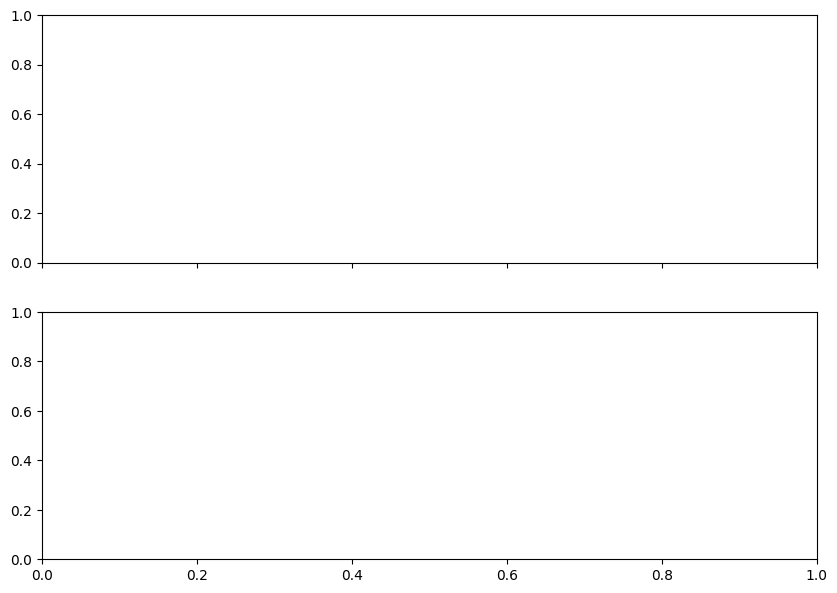

In [5]:
"""
Lab Magnetic Field Monitor with Time Axis
"""
import requests
import csv
import os
import time
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates  # <--- NEW IMPORT
from matplotlib.animation import FuncAnimation
from collections import deque

ts = time.strftime("%Y%m%d_%H%M")

# --- User Configuration ---
ARDUINO_IP = "192.168.1.22"   # <--- REPLACE with your actual IP
LOG_FILE_NAME = f"lab_magnetic_data_{ts}.csv"
UPDATE_INTERVAL = 1000        # Update graph every 1000ms (1 seconds)
MAX_POINTS = 100              # Points to keep on graph

# --- Global Variables for Plotting ---
x_vals = deque(maxlen=MAX_POINTS)
y_vals = deque(maxlen=MAX_POINTS)
z_vals = deque(maxlen=MAX_POINTS)
total_vals = deque(maxlen=MAX_POINTS)
time_vals = deque(maxlen=MAX_POINTS)

# Construct URL
url = f"http://{ARDUINO_IP}/data"

def init_csv():
    """Create CSV file if it doesn't exist."""
    if not os.path.exists(LOG_FILE_NAME):
        with open(LOG_FILE_NAME, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Timestamp", "Field_X", "Field_Y", "Field_Z", "Total", "Unit"])


def fetch_and_log():
    """Fetches data, logs to CSV, and returns values for plotting."""
    try:
        response = requests.get(url, timeout=2.0)
        if response.status_code == 200:
            data = response.json()
            
            # Extract data
            bx = data['x']
            by = data['y']
            bz = data['z']
            bt = (bx**2 + by**2 + bz**2) ** 0.5
            
            # Get current time object
            now_obj = datetime.now() # Keep as object for plotting
            now_str = now_obj.strftime("%Y-%m-%d %H:%M:%S") # String for CSV
            
            # Log to CSV
            with open(LOG_FILE_NAME, mode='a', newline='') as file:
                writer = csv.writer(file)
                # Save actual values to CSV
                writer.writerow([now_str, bx * 10, by * 10, bz * 10, bt * 10, "mG"])
            
            print(f"Logged: X:{bx * 10:.1f} Y:{by * 10:.1f} Z:{bz * 10:.1f} Total:{bt * 10:.1f}")
            
            # Return the datetime OBJECT, not the string, for the graph
            return now_obj, bx, by, bz, bt
            
    except Exception as e:
        print(f"Data fetch error: {e}")
        
    return None

def update_plot(frame):
    """This function is called by Matplotlib repeatedly."""
    result = fetch_and_log()
    
    if result:
        t, x, y, z, tot = result
        
        # Add new data to buffers
        time_vals.append(t)
        x_vals.append(x)
        y_vals.append(y)
        z_vals.append(z)
        total_vals.append(tot)
        
        # Convert Deques to Lists and apply Math ( * 10 for mG conversion)
        # Note: You cannot do "deque * 10" in Python, it must be a list comprehension
        x_list = [val * 10 for val in x_vals]
        y_list = [val * 10 for val in y_vals]
        z_list = [val * 10 for val in z_vals]
        t_list = [val * 10 for val in total_vals]
        
        # --- Update Plot 1 (Components) ---
        ax1.cla() 
        # Plot Time vs Value
        ax1.plot(time_vals, x_list, label='X Axis', color='red', linestyle='--')
        ax1.plot(time_vals, y_list, label='Y Axis', color='green', linestyle='--')
        ax1.plot(time_vals, z_list, label='Z Axis', color='blue', linestyle='--')
        ax1.legend(loc='upper left')
        ax1.set_title("Magnetic Field Components (mG)")
        ax1.grid(True, alpha=0.3)
        ax1.set_ylabel("Field Strength (mG)")
        
        # --- Update Plot 2 (Total Magnitude) ---
        ax2.cla()
        ax2.plot(time_vals, t_list, label='Total Field', color='black', linewidth=2)
        ax2.legend(loc='upper left')
        ax2.set_title("Total Magnetic Field Strength")
        ax2.grid(True, alpha=0.3)
        ax2.set_ylabel("Magnitude (mG)")
        ax2.set_xlabel("Time (mm-dd-HH-MM)")
        
        # --- DATE FORMATTING LOGIC ---
        # Define the format: Month-Day-Hour-Minute
        myFmt = mdates.DateFormatter('%m-%d-%H-%M')
        ax2.xaxis.set_major_formatter(myFmt)
        
        # Auto-rotate dates to prevent overlap
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# --- Main Execution ---
if __name__ == "__main__":
    print("Starting Real-Time Plotter...")
    init_csv()
    
    # Setup Figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(bottom=0.2) # Make room for angled date labels
    
    ani = FuncAnimation(fig, update_plot, interval=UPDATE_INTERVAL, cache_frame_data=False)
    
    plt.show()

In [8]:
result = fetch_and_log()

Logged: X:452.4 Y:-46.4 Z:228.3 Total:508.9
